## In this notebook i am goona do EDA of housing dataset ## 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


#### load the dataset ####

In [2]:
df=pd.read_csv("housing.csv")

#### getting overview of data ####

In [3]:
df.head()
df.tail()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


In [4]:
print(f"Shape of the dataset: {df.shape}")
df.info()
df.describe()

Shape of the dataset: (20640, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


#### handiling missing and duplicate values ####

In [5]:
df.isnull().sum()
#fills only numeric data becauce we have missing in only numeric values
df.fillna(df.mean(numeric_only=np.number),inplace=True)
#handiling dublicate values
print(f"Dublicate vakues are:{df.duplicated().sum()}")
#actually duplicate values are 0 in our case but if there then we have to use drop duplicates
df.drop_duplicates(inplace=True)

Dublicate vakues are:0


#### checking correlation between features using heatmap ####

<Axes: >

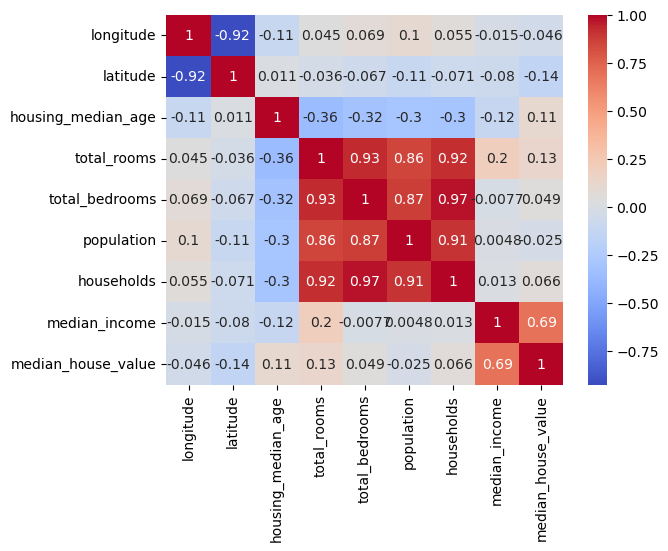

In [6]:
sns.heatmap(df.select_dtypes(include=np.number).corr(),annot=True,cmap="coolwarm")

In [ ]:
print("Here we can see our targeted column is median_house_value is correlated with median income")

Here we can see our targeted colum is median_house_vale is correlated with median income


#### numerical columns analysis ####

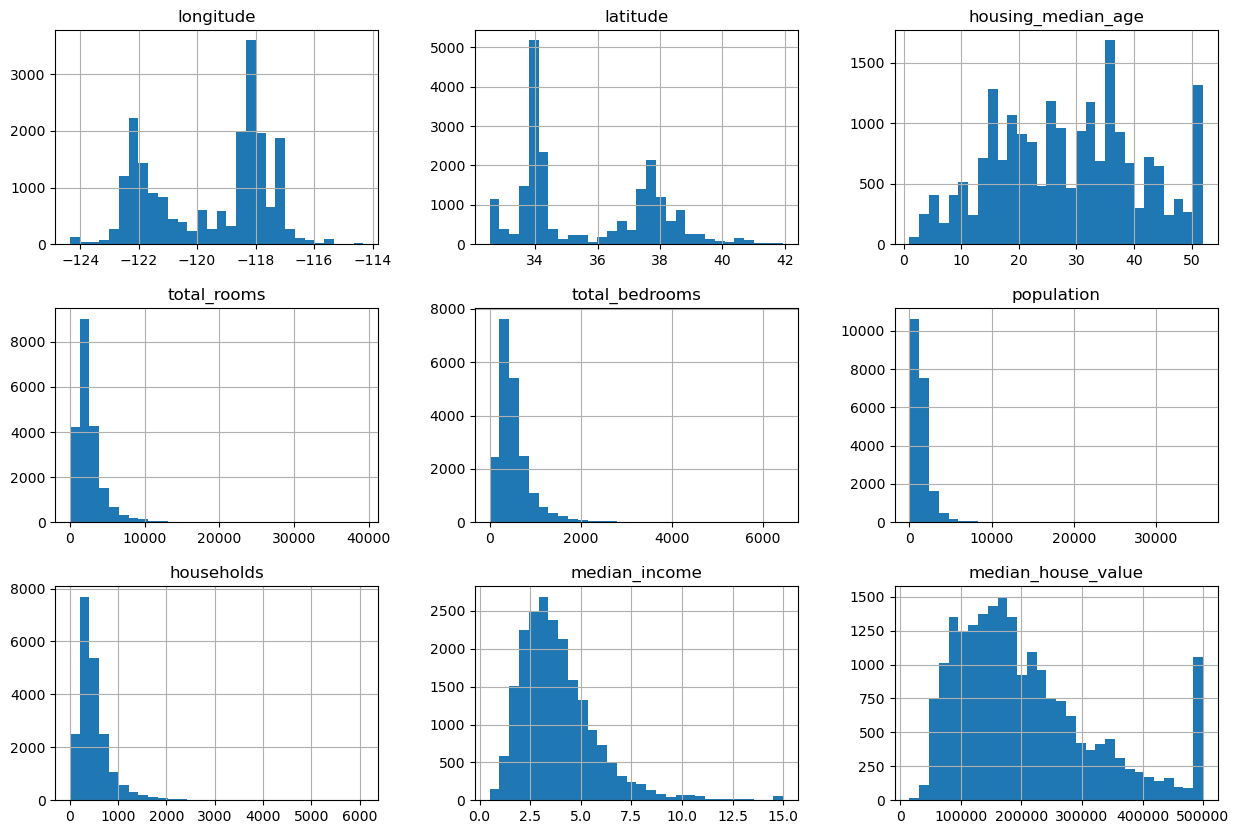

In [9]:
df.hist(figsize=(15,10),bins=30)
plt.show()

#### scatter plot for targeted column and its correkated column ####

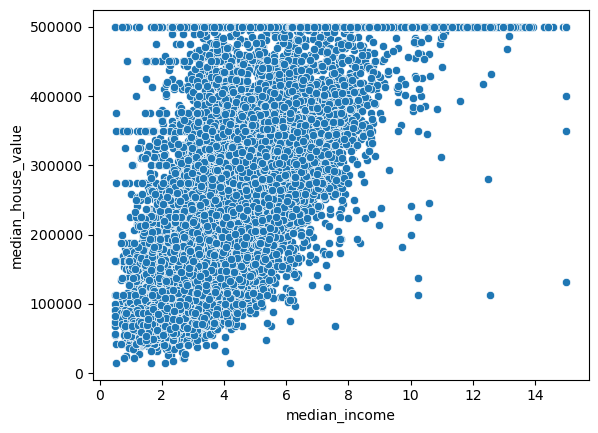

In [23]:
sns.scatterplot(x="median_income",y="median_house_value",data=df)
plt.show()

#### categorrical analysis ####

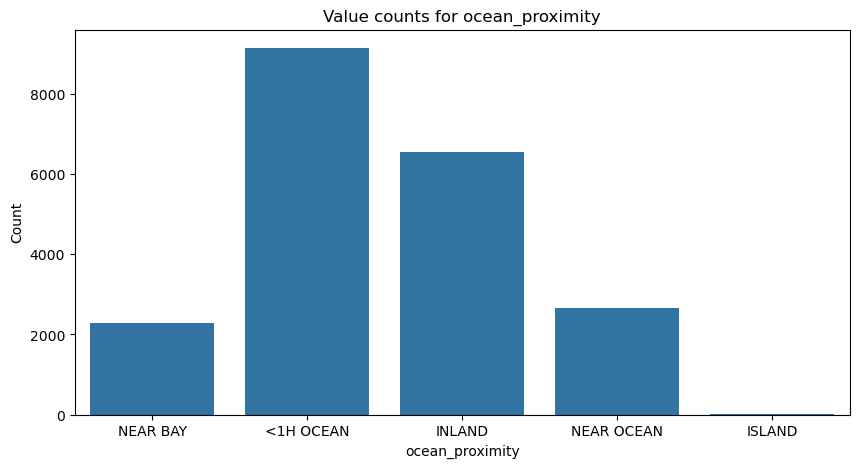

In [ ]:
categorical_cols=df.select_dtypes(include="object").columns
for col in categorical_cols:
    plt.figure(figsize=(10,5))
    sns.countplot(x=col,data=df)
    plt.title(f"Value counts for {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()



#### outliers of each column ####

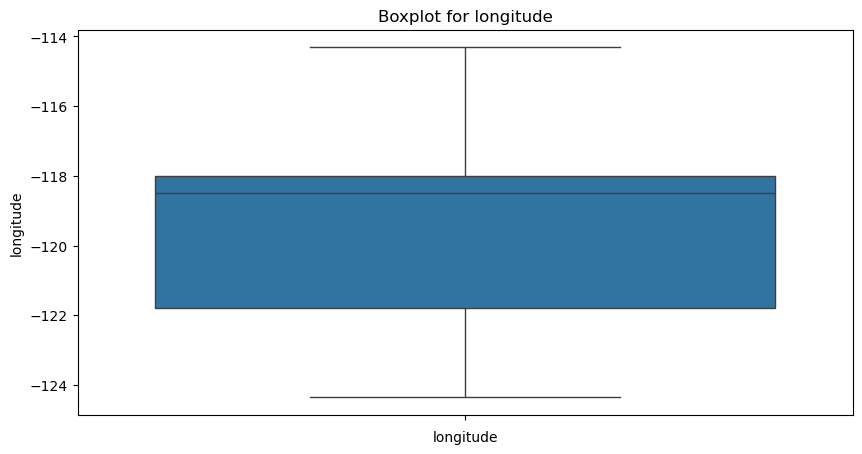

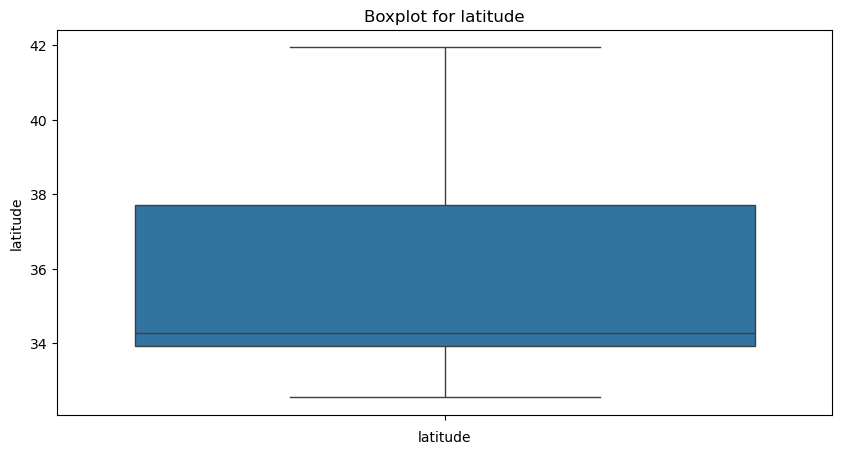

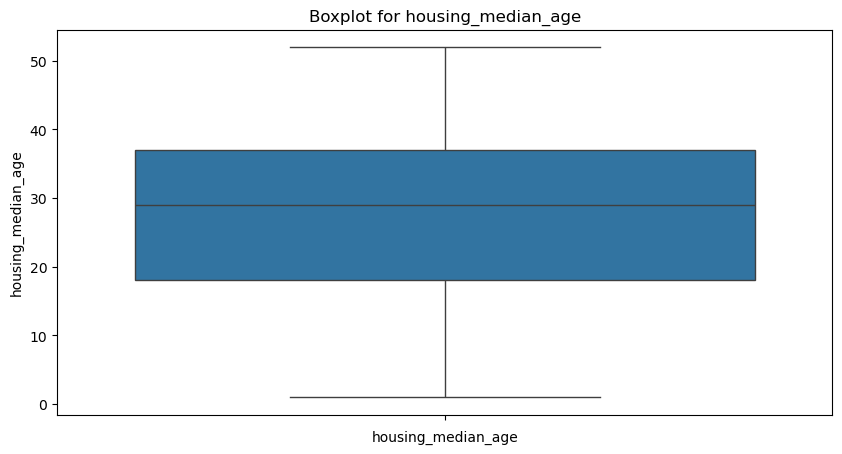

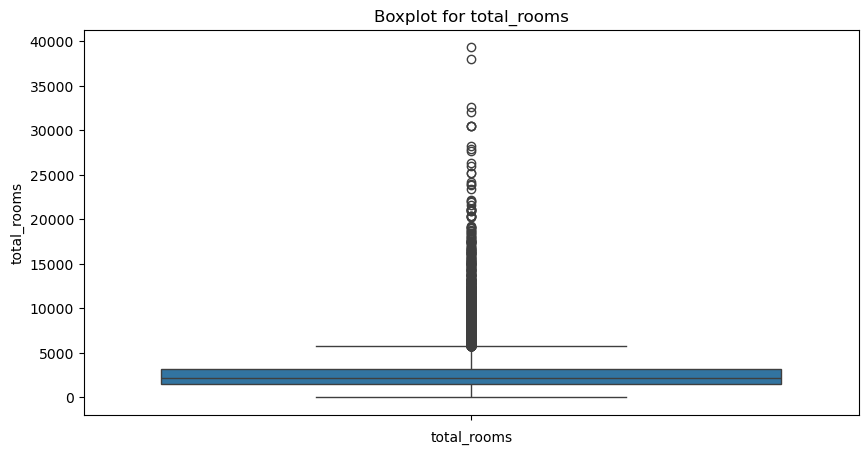

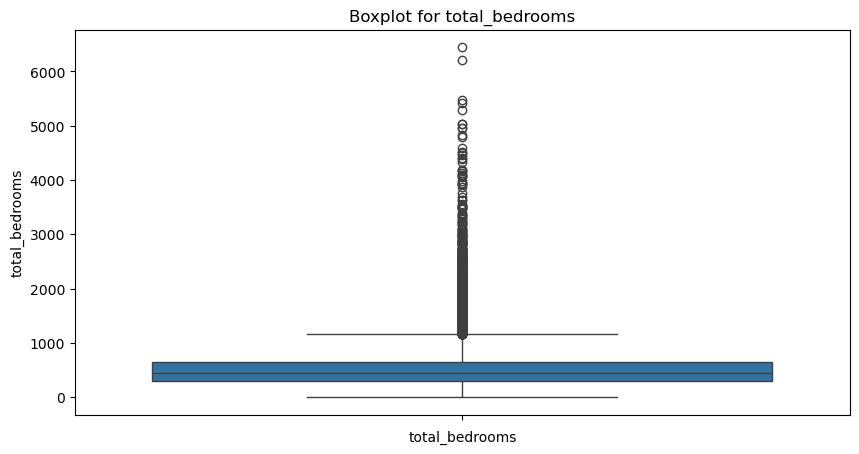

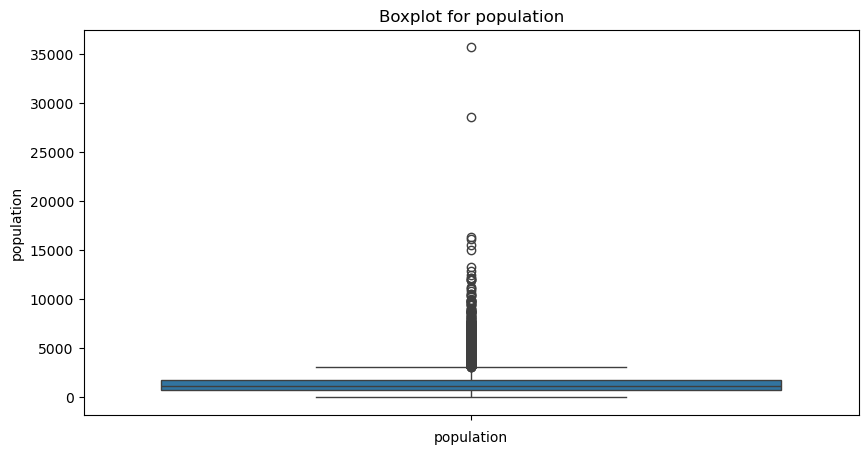

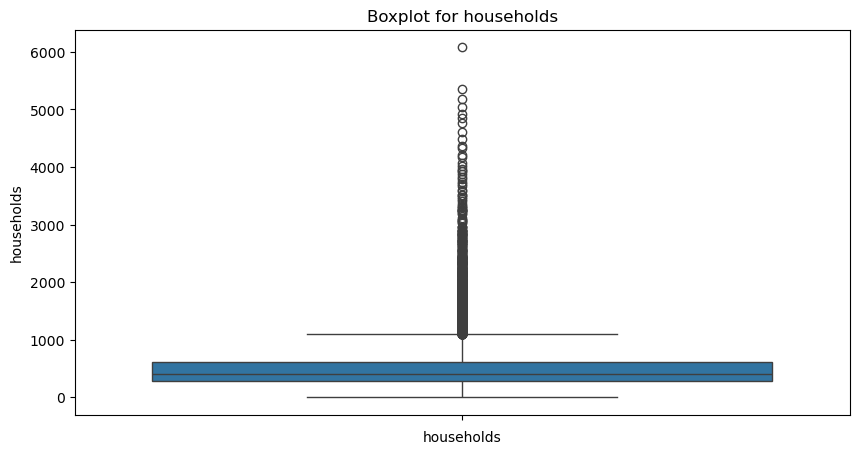

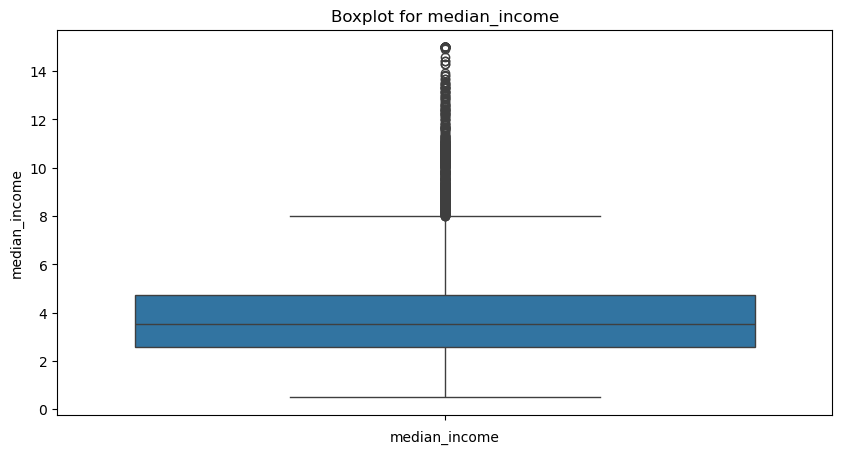

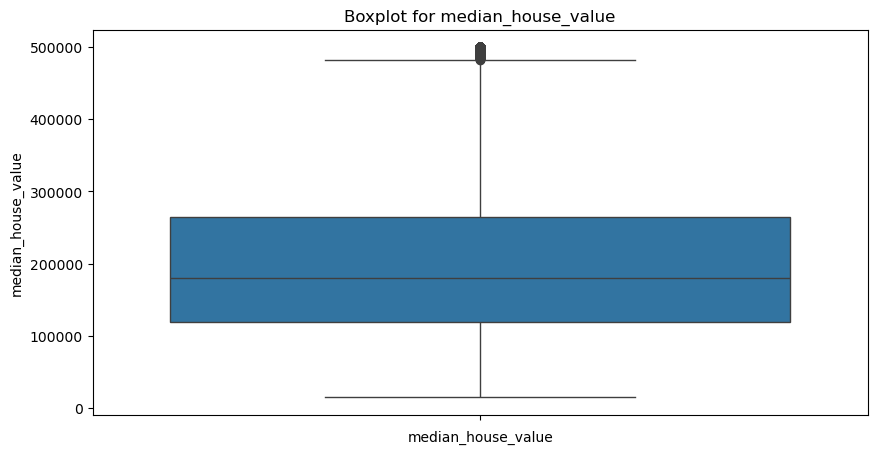

In [20]:
numerical_cols=df.select_dtypes(include=np.number).columns
for col in numerical_cols:
    plt.figure(figsize=(10,5))
    sns.boxplot(y=df[col])
    plt.xticks(rotation=90)
    plt.title(f"Boxplot for {col}")
    plt.xlabel(col)
    plt.show()

#### categorical encoding ####

In [21]:
df = pd.get_dummies(df, drop_first=True)

In [22]:
df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False
